In [17]:
# =========================
# 1. BIBLIOTECAS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [18]:
# =========================
# DADOS DE PRODUÇÃO BRASIL QUANTIDADE BENEFICIADA CONTIDA EM TONELADAS MÉTRICAS: 
# =========================
litio_br = pd.DataFrame({
    "Ano": [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 
            2020, 2021, 2022, 2023, 2024],
    
    "Litio_Brasil": [
        363.10, 323.25,365.52,415.86,451.51,308.13,440.20,562.16,786.10,2574.75,4064.75,5669.95,7862.85,15193.04,25978.52
    ]
})
print(litio_br)

     Ano  Litio_Brasil
0   2010        363.10
1   2011        323.25
2   2012        365.52
3   2013        415.86
4   2014        451.51
5   2015        308.13
6   2016        440.20
7   2017        562.16
8   2018        786.10
9   2019       2574.75
10  2020       4064.75
11  2021       5669.95
12  2022       7862.85
13  2023      15193.04
14  2024      25978.52


In [19]:
# =========================
# DADOS DE PRODUÇÃO BRASIL BENEFICIADA EM TONELADAS MÉTRICAS: 
# =========================
litio_br = pd.DataFrame({
    "Ano": [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 
            2020, 2021, 2022, 2023, 2024],
    
    "Litio_Bruto": [
        7262, 6401,6504,7982,8519,5781,8804,10547,17354,47818.04,74100.63,102937.74,143719.73,263876.03,944114.38
    ]
})
print(litio_br)

     Ano  Litio_Bruto
0   2010      7262.00
1   2011      6401.00
2   2012      6504.00
3   2013      7982.00
4   2014      8519.00
5   2015      5781.00
6   2016      8804.00
7   2017     10547.00
8   2018     17354.00
9   2019     47818.04
10  2020     74100.63
11  2021    102937.74
12  2022    143719.73
13  2023    263876.03
14  2024    944114.38


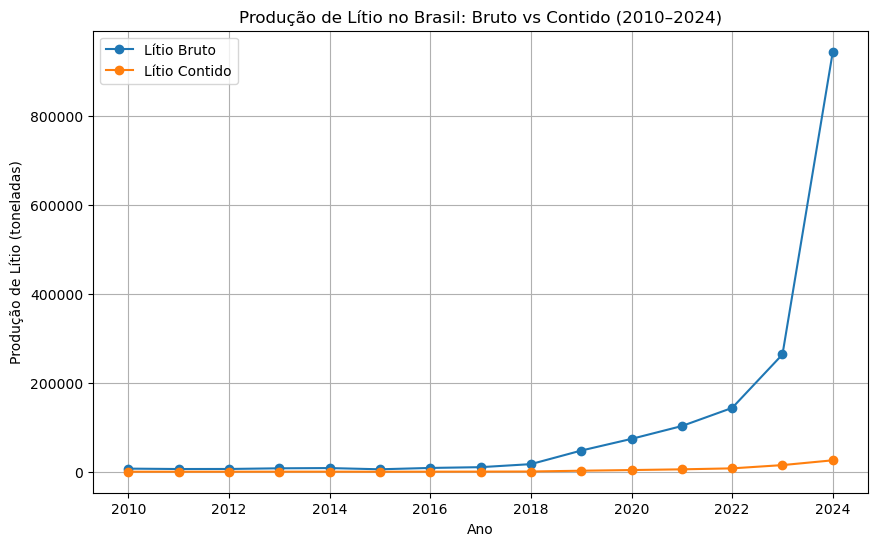

In [90]:
import matplotlib.pyplot as plt

# 🔹 Garantir que os dois DataFrames existem
# (corrigindo o problema de sobrescrita)

litio_br_liquido = pd.DataFrame({
    "Ano": [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 
            2020, 2021, 2022, 2023, 2024],
    "Litio_Contido": [
        363.10, 323.25, 365.52, 415.86, 451.51, 308.13, 440.20, 562.16, 
        786.10, 2574.75, 4064.75, 5669.95, 7862.85, 15193.04, 25978.52
    ]
})

litio_br_bruto = pd.DataFrame({
    "Ano": [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 
            2020, 2021, 2022, 2023, 2024],
    "Litio_Bruto": [
        7262, 6401, 6504, 7982, 8519, 5781, 8804, 10547, 17354, 
        47818.04, 74100.63, 102937.74, 143719.73, 263876.03, 944114.38
    ]
})

# 🔹 Juntar os dois
df_litio = pd.merge(litio_br_liquido, litio_br_bruto, on="Ano")

# 🔹 Criar gráfico
plt.figure(figsize=(10,6))

plt.plot(df_litio["Ano"], df_litio["Litio_Bruto"], label="Lítio Bruto", marker='o')
plt.plot(df_litio["Ano"], df_litio["Litio_Contido"], label="Lítio Contido", marker='o')

# 🔹 Configurações
plt.xlabel("Ano")
plt.ylabel("Produção de Lítio (toneladas)")
plt.title("Produção de Lítio no Brasil: Bruto vs Contido (2010–2024)")
plt.legend()
plt.grid()

plt.show()

In [21]:
# =========================
# 2. LÍTIO GLOBAL EM TONELADA MÉTRICA BENEFICIADA
# =========================

import pandas as pd

df = pd.read_csv("lithium_production.csv")

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Lithium Production"] = pd.to_numeric(df["Lithium Production"], errors="coerce")

df_filtrado = df[(df["Year"] >= 2010) & (df["Year"] <= 2024)]

producao_global = df_filtrado.groupby("Year")["Lithium Production"].sum()


producao_global = producao_global.reset_index()
producao_global["Lithium Production"] = producao_global["Lithium Production"].round(2)

print(producao_global)



    Year  Lithium Production
0   2010           105437.28
1   2011           131665.36
2   2012           137923.83
3   2013           120566.02
4   2014           122864.56
5   2015           117272.34
6   2016           151849.11
7   2017           202428.85
8   2018           373017.13
9   2019           345666.47
10  2020           334223.53
11  2021           430525.62
12  2022           628897.19
13  2023           818490.61
14  2024           941731.59


In [22]:
# =========================
# 3. VEÍCULOS ELÉTRICOS
# =========================
import pandas as pd

# Ler Excel
df = pd.read_excel("EVData.xlsx")

# Limpar nomes das colunas
df.columns = df.columns.astype(str).str.strip()

print("Colunas originais:")
print(df.columns)

# Criar dicionário para renomear anos (2.010 -> 2010)
novos_nomes = {}

for col in df.columns:
    col_limpa = col.replace(".", "")
    if col_limpa.isdigit() and len(col_limpa) == 4:
        novos_nomes[col] = col_limpa

# Renomear
df = df.rename(columns=novos_nomes)

print("\nColunas corrigidas:")
print(df.columns)

# Selecionar apenas colunas de ano automaticamente
anos = [col for col in df.columns if col.isdigit() and 2010 <= int(col) <= 2024]

print("\nAnos encontrados:", anos)

# Converter valores
for col in anos:
    df[col] = df[col].astype(str).str.replace(".", "", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Somar
df["Total_Vendas"] = df[anos].sum(axis=1)

# Resultado
resultado = df[["region_country", "Total_Vendas"]]

print("\nResultado final:")
print(resultado.sort_values(by="Total_Vendas", ascending=False))

Colunas originais:
Index(['region_country', '2.010', '2.011', '2.012', '2.013', '2.014', '2.015',
       '2.016', '2.017', '2.018', '2.019', '2.020', '2.021', '2.022', '2.023',
       '2.024'],
      dtype='object')

Colunas corrigidas:
Index(['region_country', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'],
      dtype='object')

Anos encontrados: ['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']

Resultado final:
               region_country  Total_Vendas
55                      World   308250000.0
8                       China   175695000.0
52                        USA    36850000.0
18                    Germany    16170400.0
51             United Kingdom    10813400.0
17                     France     9943900.0
36                     Norway     6701600.0
5                      Canada     4685400.0
28                      Korea     

In [7]:
# =========================
# 4. BATERIAS DE CARRO ELÉTRICO EM GWH/ano
# =========================
import pandas as pd

# Criar o DataFrame com os dados fornecidos
dados = {
    "Year": [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    "China": [38, 56, 70, 75, 80, 179, 314, 417],
    "Europe": [5, 8, 12, 25, 54, 93, 129, 185],
    "United States": [6, 8, 19, 19, 19, 38, 70, 99],
    "Rest of world": [2, 3, 7, 9, 12, 21, 41, 71]
}

df = pd.DataFrame(dados)

# Arredondar (caso precise)
df = df.round(2)

# Mostrar tabela

print(df.to_string(index=False))

 Year  China  Europe  United States  Rest of world
 2016     38       5              6              2
 2017     56       8              8              3
 2018     70      12             19              7
 2019     75      25             19              9
 2020     80      54             19             12
 2021    179      93             38             21
 2022    314     129             70             41
 2023    417     185             99             71


In [23]:
import pandas as pd

# =========================
# 5. ENERGIA RENOVÁVEL
# =========================
import pandas as pd

# Ler o arquivo
df_renovavel = pd.read_csv("electricity-generation-from-renewables.csv")

# Renomear colunas
df_renovavel.rename(columns={
    "Year": "Ano",
    "Renewables": "Energia_Renovavel"
}, inplace=True)

# Converter para numérico (segurança)
df_renovavel["Ano"] = pd.to_numeric(df_renovavel["Ano"], errors="coerce")
df_renovavel["Energia_Renovavel"] = pd.to_numeric(df_renovavel["Energia_Renovavel"], errors="coerce")

# 🔥 Filtrar período (2010–2024)
df_filtrado = df_renovavel[
    (df_renovavel["Ano"] >= 2010) &
    (df_renovavel["Ano"] <= 2024)
]

# 🔥 Somar todas as entidades por ano
df_global = df_filtrado.groupby("Ano")["Energia_Renovavel"].sum().reset_index()

# 🔥 Limitar para 2 casas decimais
df_global["Energia_Renovavel"] = df_global["Energia_Renovavel"].round(2)

# Mostrar resultado
print(df_global.to_string(index=False))

 Ano  Energia_Renovavel
2010           37371.30
2011           39267.07
2012           42109.71
2013           44952.72
2014           47264.87
2015           49250.94
2016           52249.46
2017           55465.07
2018           59147.87
2019           62276.20
2020           66598.36
2021           70345.66
2022           75264.14
2023           77247.68
2024           68671.66


In [25]:
litio_br_liquido.rename(columns={
    "Ano": "Ano",
    "Litio_Contido": "Litio_Brasil"
}, inplace=True)

In [26]:
import pandas as pd

df = pd.read_excel("EVData.xlsx")

# Limpar nomes
df.columns = df.columns.astype(str).str.strip()
novos_nomes = {}

for col in df.columns:
    col_limpa = col.replace(".", "")
    if col_limpa.isdigit() and len(col_limpa) == 4:
        novos_nomes[col] = col_limpa

df = df.rename(columns=novos_nomes)

print(df.columns)
anos = [col for col in df.columns if col.isdigit() and 2010 <= int(col) <= 2024]

print("Anos:", anos)
for col in anos:
    df[col] = df[col].astype(str).str.replace(".", "", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce")
    vendas_anuais = df[anos].sum(axis=0)
    df_ev = vendas_anuais.reset_index()
df_ev.columns = ["Ano", "Vendas_EV"]

df_ev["Ano"] = pd.to_numeric(df_ev["Ano"])
df_ev["Vendas_EV"] = df_ev["Vendas_EV"].round(2)

print(df_ev)

Index(['region_country', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'],
      dtype='object')
Anos: ['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
     Ano    Vendas_EV
0   2010     139380.0
1   2011     802930.0
2   2012    1161800.0
3   2013    2244390.0
4   2014    3963500.0
5   2015    6607120.0
6   2016    9390950.0
7   2017   15182460.0
8   2018   27843690.0
9   2019   30504470.0
10  2020   40274470.0
11  2021   93667900.0
12  2022  146469270.0
13  2023   19009260.0
14  2024  219484000.0


In [29]:
# =========================
# GARANTIR COLUNA "Ano"
# =========================
producao_global = producao_global.rename(columns={"Year": "Ano"})
df_global = df_global.rename(columns={"Year": "Ano"})

# =========================
# DATAFRAME BATERIAS
# =========================
df_bat = pd.DataFrame({
    "Ano": [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    "China": [38, 56, 70, 75, 80, 179, 314, 417],
    "Europe": [5, 8, 12, 25, 54, 93, 129, 185],
    "United States": [6, 8, 19, 19, 19, 38, 70, 99],
    "Rest of world": [2, 3, 7, 9, 12, 21, 41, 71]
})

df_bat["Baterias_Global"] = df_bat[
    ["China", "Europe", "United States", "Rest of world"]
].sum(axis=1)

df_bat = df_bat[["Ano", "Baterias_Global"]]

# =========================
# MERGE FINAL
# =========================
df_final = producao_global.merge(df_bat, on="Ano", how="inner")
df_final = df_final.merge(df_global, on="Ano", how="inner")
df_final = df_final.merge(litio_br_liquido, on="Ano", how="inner")
df_final = df_final.merge(df_ev, on="Ano", how="inner")

df_final = df_final.sort_values("Ano")

print(df_final)

    Ano  Lithium Production  Baterias_Global  Energia_Renovavel  Litio_Brasil  \
0  2016           151849.11               51           52249.46        440.20   
1  2017           202428.85               75           55465.07        562.16   
2  2018           373017.13              108           59147.87        786.10   
3  2019           345666.47              128           62276.20       2574.75   
4  2020           334223.53              165           66598.36       4064.75   
5  2021           430525.62              331           70345.66       5669.95   
6  2022           628897.19              554           75264.14       7862.85   
7  2023           818490.61              772           77247.68      15193.04   

     Vendas_EV  
0    9390950.0  
1   15182460.0  
2   27843690.0  
3   30504470.0  
4   40274470.0  
5   93667900.0  
6  146469270.0  
7   19009260.0  


In [30]:
# Padronizar tudo
producao_global["Ano"] = pd.to_numeric(producao_global["Ano"])
df_bat["Ano"] = pd.to_numeric(df_bat["Ano"])
df_global["Ano"] = pd.to_numeric(df_global["Ano"])
litio_br_liquido["Ano"] = pd.to_numeric(litio_br_liquido["Ano"])
df_ev["Ano"] = pd.to_numeric(df_ev["Ano"])

print("Lítio:", producao_global["Ano"].unique())
print("Baterias:", df_bat["Ano"].unique())
print("Renovável:", df_global["Ano"].unique())
print("Brasil:", litio_br_liquido["Ano"].unique())
print("EV:", df_ev["Ano"].unique())

df_final = producao_global.merge(df_bat, on="Ano", how="inner")
print("Depois baterias:", df_final.shape)

df_final = df_final.merge(df_global, on="Ano", how="inner")
print("Depois renovável:", df_final.shape)

df_final = df_final.merge(litio_br_liquido, on="Ano", how="inner")
print("Depois Brasil:", df_final.shape)

df_final = df_final.merge(df_ev, on="Ano", how="inner")
print("Depois EV:", df_final.shape)

Lítio: [2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
 2024]
Baterias: [2016 2017 2018 2019 2020 2021 2022 2023]
Renovável: [2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
 2024]
Brasil: [2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
 2024]
EV: [2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
 2024]
Depois baterias: (8, 3)
Depois renovável: (8, 4)
Depois Brasil: (8, 5)
Depois EV: (8, 6)


In [34]:
# =========================
# 13. MODELO
# =========================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# =========================
# VARIÁVEIS
# =========================
X = df_final[[
    "Lithium Production",
    "Litio_Brasil",
    "Energia_Renovavel",
    "Vendas_EV"
]]

y = df_final["Baterias_Global"]

# =========================
# TREINO
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

# =========================
# PREVISÃO (TESTE)
# =========================
y_pred = modelo.predict(X_test)

In [37]:
from IPython.display import display

metricas = pd.DataFrame({
    "Métrica": ["R²", "RMSE", "RMSRE"],
    
    "Valor": [
        round(r2, 4),
        round(rmse, 2),
        round(rmsre, 4)
    ],
    
    "Significado": [
        "Proporção da variância da variável dependente explicada pelo modelo",
        "Erro médio absoluto entre valores reais e previstos na unidade original",
        "Erro relativo médio entre valores reais e previstos (em proporção)"
    ],
    
    "Interpretação": [
        "Excelente poder explicativo (modelo explica ~96% da variação dos dados)",
        "Erro baixo em relação à escala dos dados observados",
        "Erro relativo moderado (~31%), indicando variação não explicada pelo modelo"
    ]
})

display(metricas)

,Métrica,Valor,Significado,Interpretação
0,R²,0.9661,Proporção da variância da variável dependente ...,Excelente poder explicativo (modelo explica ~9...
1,RMSE,23.5500,Erro médio absoluto entre valores reais e prev...,Erro baixo em relação à escala dos dados obser...
2,RMSRE,0.3111,Erro relativo médio entre valores reais e prev...,"Erro relativo moderado (~31%), indicando varia..."


In [38]:
from IPython.display import display

# =========================
# FUNÇÕES DE CLASSIFICAÇÃO
# =========================
def nivel_r2(r2):
    if r2 >= 0.9:
        return "🟢 Excelente"
    elif r2 >= 0.7:
        return "🟡 Bom"
    else:
        return "🔴 Baixo"

def nivel_rmse(rmse):
    # quanto menor, melhor
    if rmse <= 30:
        return "🟢 Baixo erro"
    elif rmse <= 80:
        return "🟡 Erro moderado"
    else:
        return "🔴 Alto erro"

def nivel_rmsre(rmsre):
    # erro relativo
    if rmsre <= 0.2:
        return "🟢 Baixo erro relativo"
    elif rmsre <= 0.4:
        return "🟡 Erro relativo moderado"
    else:
        return "🔴 Alto erro relativo"

# =========================
# TABELA FINAL
# =========================
metricas = pd.DataFrame({
    "Métrica": ["R²", "RMSE", "RMSRE"],
    
    "Valor": [
        round(r2, 4),
        round(rmse, 2),
        round(rmsre, 4)
    ],
    
    "Significado": [
        "Proporção da variância explicada pelo modelo",
        "Erro médio absoluto na escala original",
        "Erro relativo médio entre real e previsto"
    ],
    
    "Interpretação": [
        "Capacidade explicativa do modelo",
        "Magnitude média do erro",
        "Proporção do erro em relação aos valores reais"
    ],
    
    "Qualidade do Modelo": [
        nivel_r2(r2),
        nivel_rmse(rmse),
        nivel_rmsre(rmsre)
    ]
})

display(metricas)

,Métrica,Valor,Significado,Interpretação,Qualidade do Modelo
0,R²,0.9661,Proporção da variância explicada pelo modelo,Capacidade explicativa do modelo,🟢 Excelente
1,RMSE,23.5500,Erro médio absoluto na escala original,Magnitude média do erro,🟢 Baixo erro
2,RMSRE,0.3111,Erro relativo médio entre real e previsto,Proporção do erro em relação aos valores reais,🟡 Erro relativo moderado


In [39]:
# =========================
# 16. COEFICIENTES
# =========================
coef = pd.DataFrame({
    "Variavel": X.columns,
    "Coeficiente": modelo.coef_
})

print(coef)
print("Intercepto:", modelo.intercept_)

             Variavel  Coeficiente
0  Lithium Production     0.000494
1        Litio_Brasil     0.051510
2   Energia_Renovavel    -0.015387
3           Vendas_EV     0.000002
Intercepto: 739.887218453583


In [42]:
coef_table = pd.DataFrame({
    "Variável": X.columns,
    "Coeficiente": modelo.coef_,
    "Interpretação": [
        "Impacto positivo pequeno na produção de baterias",
        "Principal variável explicativa positiva do modelo",
        "Relação inversa possivelmente por defasagem temporal",
        "Influência linear praticamente nula no modelo"
    ]
})

display(coef_table)

,Variável,Coeficiente,Interpretação
0,Lithium Production,0.000494,Impacto positivo pequeno na produção de baterias
1,Litio_Brasil,0.051510,Principal variável explicativa positiva do modelo
2,Energia_Renovavel,-0.015387,Relação inversa possivelmente por defasagem te...
3,Vendas_EV,0.000002,Influência linear praticamente nula no modelo


In [75]:
X_futuro = df_futuro[[
    "Lithium Production",
    "Litio_Brasil",
    "Energia_Renovavel",
    "Vendas_EV"
]]

df_futuro["Baterias_Previstas"] = modelo.predict(X_futuro)

print(df_futuro)

    Ano  Lithium Production  Litio_Brasil  Energia_Renovavel     Vendas_EV  \
0  2024        5.562243e+05  10767.115827       40300.581375  1.069206e+08   
1  2025        6.450380e+05  12931.023729       45206.563119  1.332052e+08   
2  2026        7.366415e+05  15193.040000       50210.992000  1.611162e+08   
3  2027        8.282451e+05  17455.056271       55215.420881  1.890272e+08   
4  2028        9.170588e+05  19618.964173       60121.402625  2.153117e+08   
5  2029        1.000622e+06  21602.968463       64838.087253  2.387017e+08   
6  2030        1.077056e+06  23352.455553       69288.606304  2.584896e+08   

   Baterias_Previstas  
0         1136.534016  
1         1262.429546  
2         1396.090573  
3         1529.751600  
4         1655.647130  
5         1767.525310  
6         1861.588076  


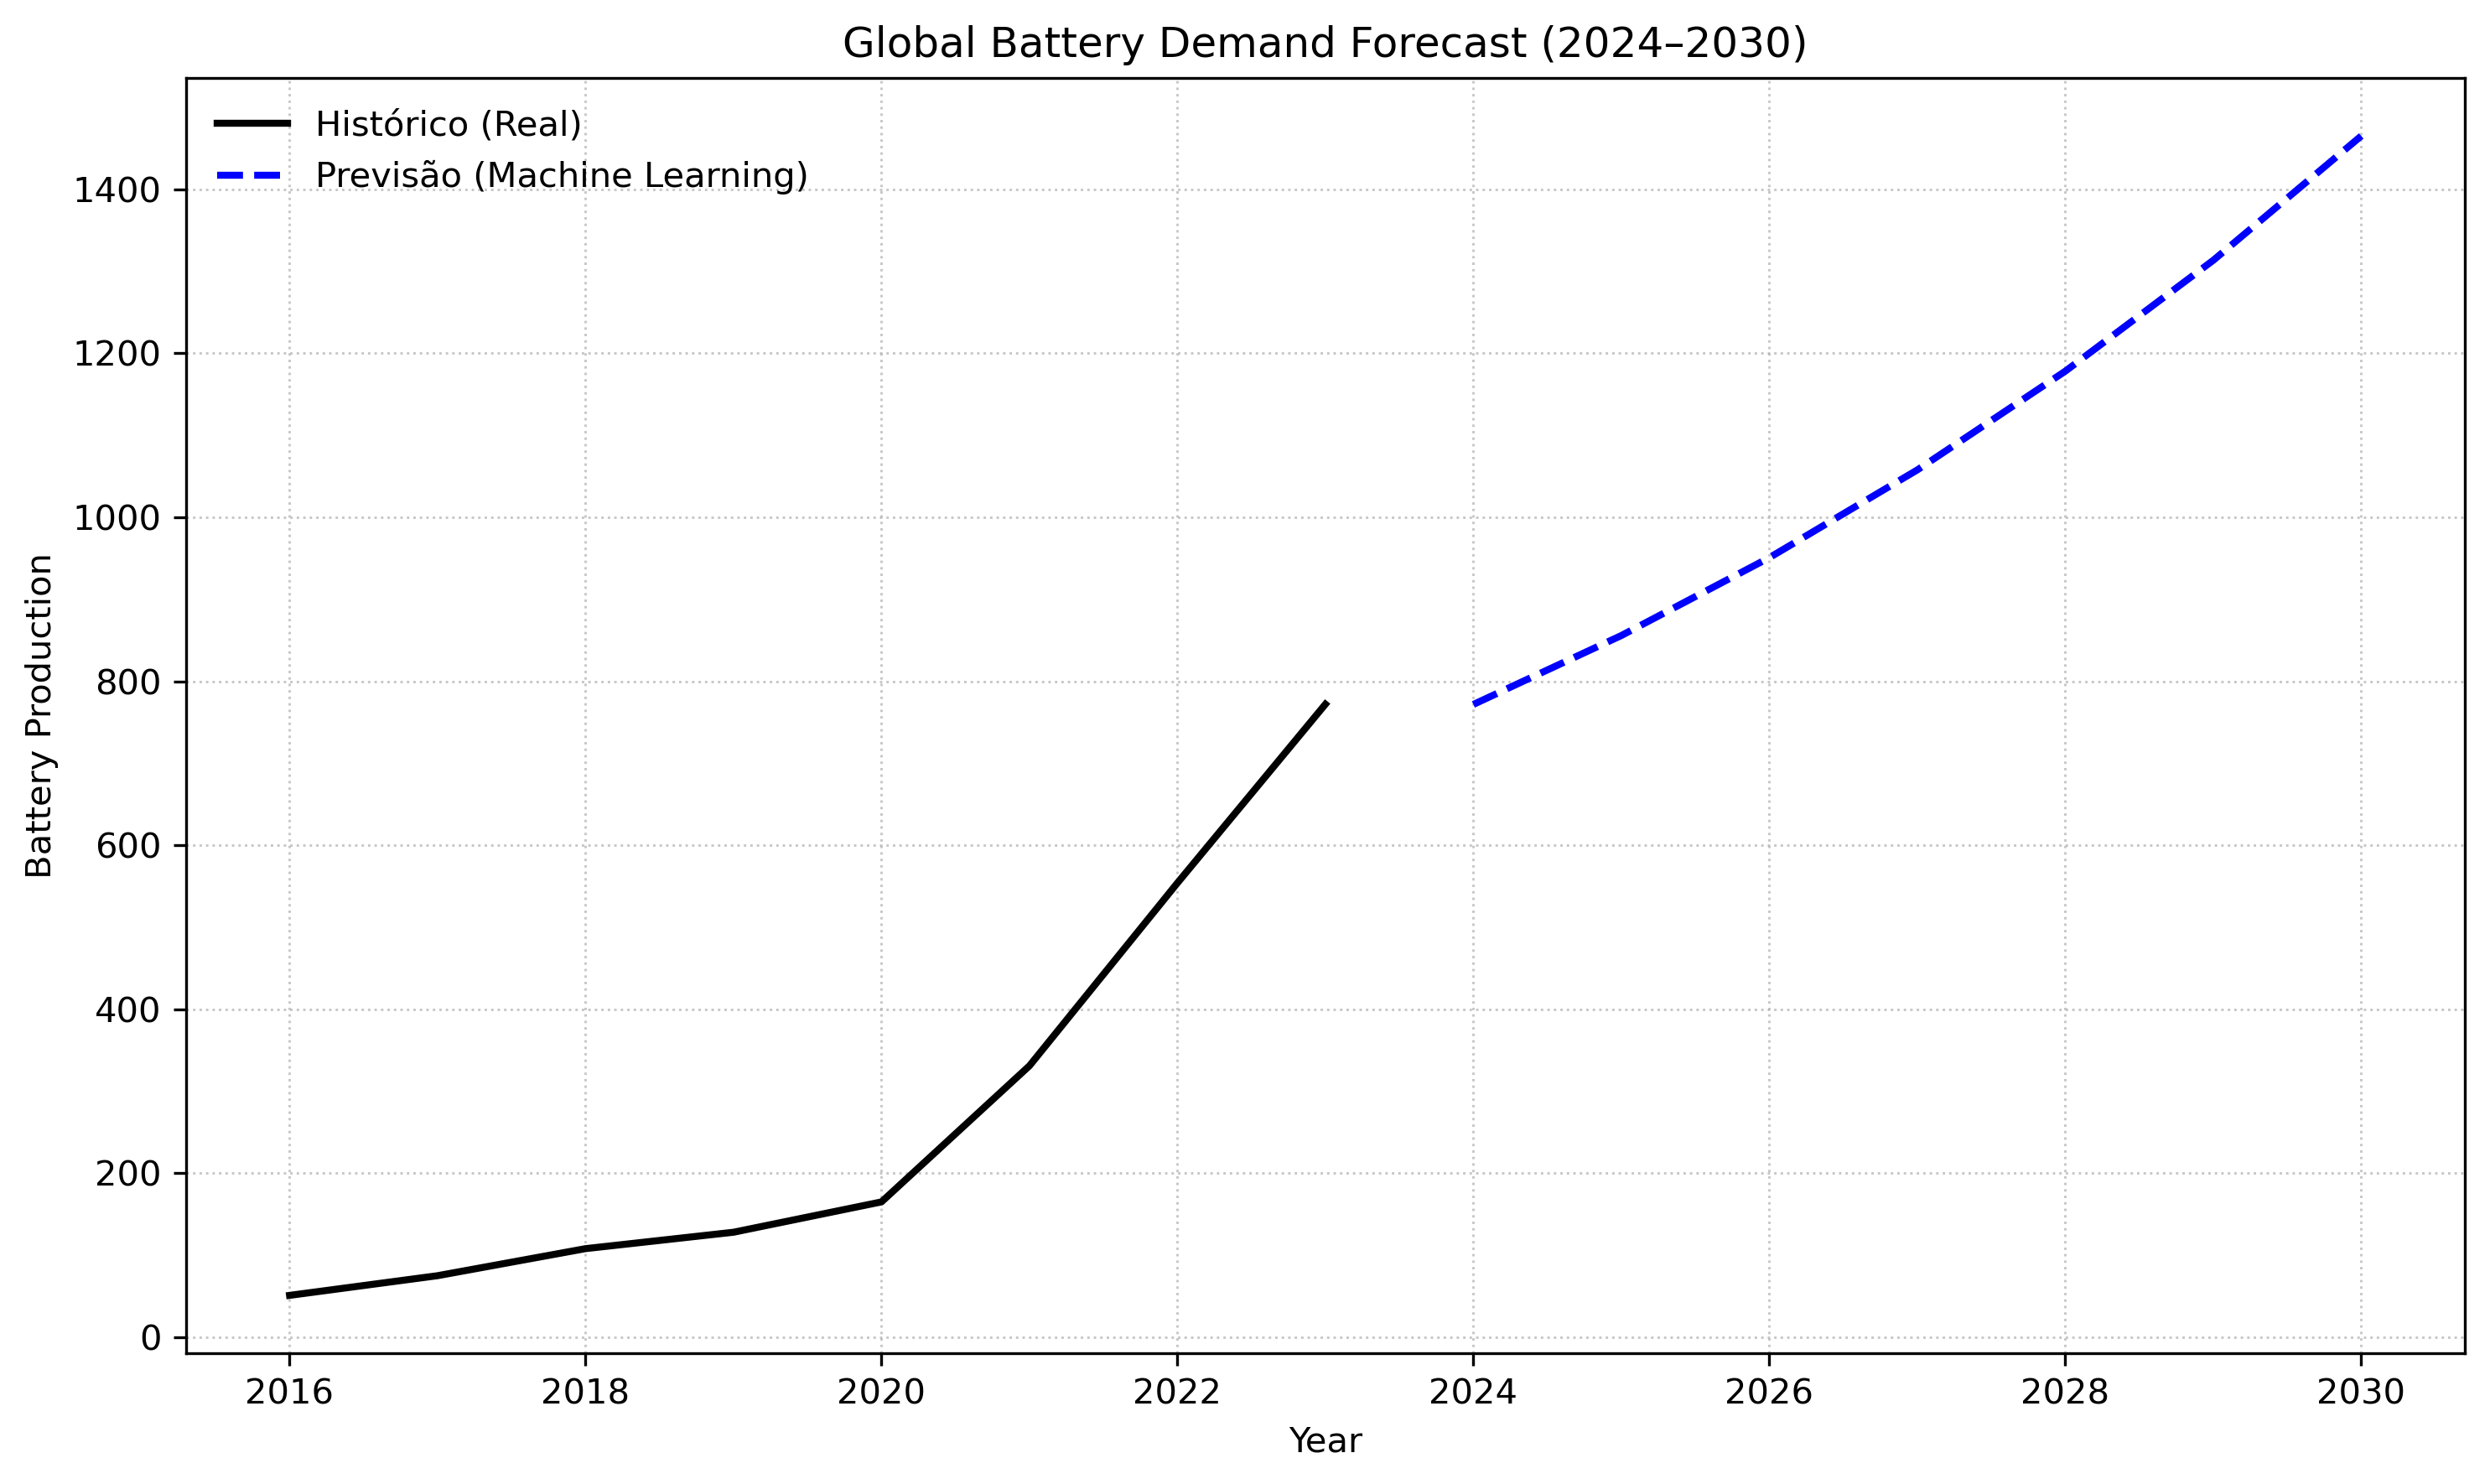

In [94]:
import matplotlib.pyplot as plt

# garantir previsão
df_futuro["Baterias_Previstas"] = modelo.predict(
    df_futuro[[
        "Lithium Production",
        "Litio_Brasil",
        "Energia_Renovavel",
        "Vendas_EV"
    ]]
)

plt.figure(figsize=(10,6), dpi=300)

# =========================
# HISTÓRICO (REAL)
# =========================
plt.plot(
    df_final["Ano"],
    df_final["Baterias_Global"],
    color="black",
    linewidth=2,
    label="Histórico (Real)"
)

# =========================
# PREVISÃO (ML)
# =========================
plt.plot(
    df_futuro["Ano"],
    df_futuro["Baterias_Previstas"],
    color="blue",
    linestyle="--",
    linewidth=2,
    label="Previsão (Machine Learning)"
)

# =========================
# ESTÉTICA CIENTÍFICA LIMPA
# =========================
plt.title("Global Battery Demand Forecast (2024–2030)", fontsize=12)
plt.xlabel("Year")
plt.ylabel("Battery Production")

plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)

plt.legend(frameon=False)

plt.tight_layout()

plt.show()

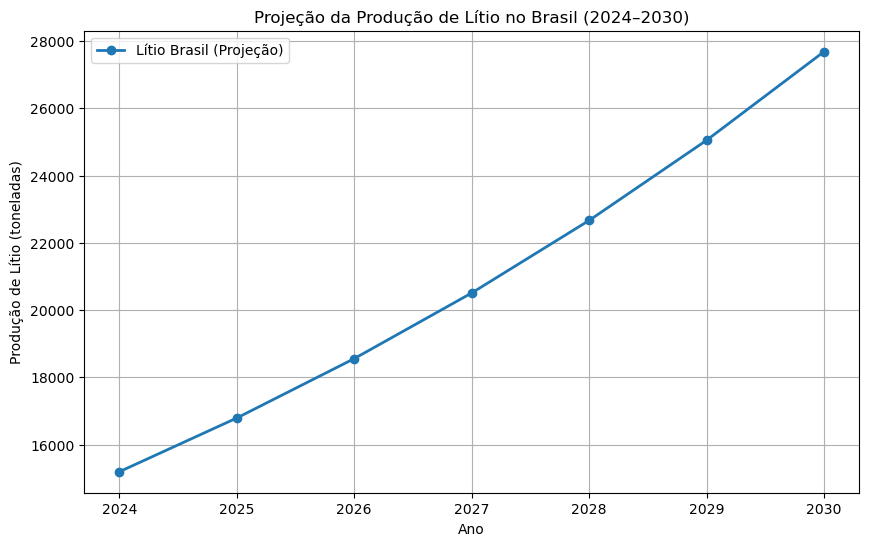

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    df_futuro["Ano"],
    df_futuro["Litio_Brasil"],
    marker="o",
    linewidth=2,
    label="Lítio Brasil (Projeção)"
)

plt.title("Projeção da Produção de Lítio no Brasil (2024–2030)")
plt.xlabel("Ano")
plt.ylabel("Produção de Lítio (toneladas)")
plt.grid()
plt.legend()

plt.show()

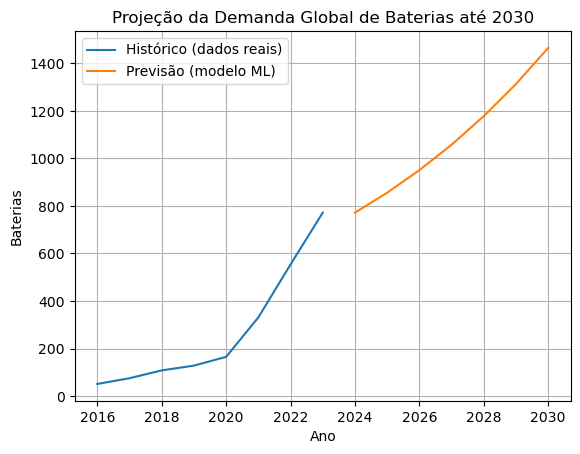

In [96]:
df_futuro["Baterias_Previstas"] = modelo.predict(
    df_futuro[[
        "Lithium Production",
        "Litio_Brasil",
        "Energia_Renovavel",
        "Vendas_EV"
    ]]
)

plt.plot(df_final["Ano"], df_final["Baterias_Global"], label="Histórico")
plt.plot(df_futuro["Ano"], df_futuro["Baterias_Previstas"], label="Previsão")

plt.xlabel("Ano")
plt.ylabel("Baterias")
plt.title("Previsão até 2030")
plt.legend()
plt.grid()
plt.title("Projeção da Demanda Global de Baterias até 2030")
plt.legend(["Histórico (dados reais)", "Previsão (modelo ML)"])
plt.show()

In [78]:
import numpy as np
import pandas as pd

anos_futuros = np.array(range(2024, 2031))
t0 = 2024  # ano base

def exponential(base_value, growth_rate, t):
    return base_value * np.exp(growth_rate * (t - t0))

df_futuro = pd.DataFrame({
    "Ano": anos_futuros,

    "Lithium Production": exponential(
        df_final["Lithium Production"].iloc[-1],
        0.08,
        anos_futuros
    ),

    "Litio_Brasil": exponential(
        df_final["Litio_Brasil"].iloc[-1],
        0.10,
        anos_futuros
    ),

    "Energia_Renovavel": exponential(
        df_final["Energia_Renovavel"].iloc[-1],
        0.03,
        anos_futuros
    ),

    "Vendas_EV": exponential(
        df_final["Vendas_EV"].iloc[-1],
        0.12,
        anos_futuros
    )
})

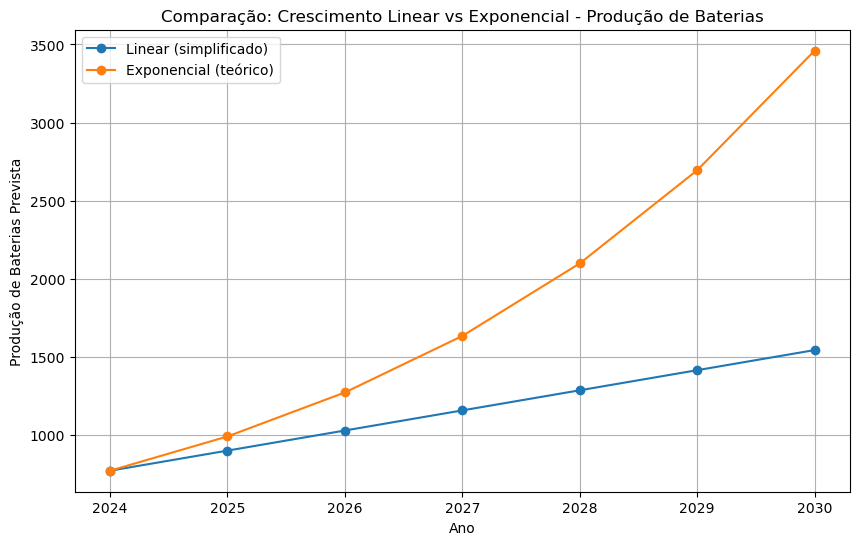

In [97]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# ANOS FUTUROS
# =========================
anos_futuros = np.array(range(2024, 2031))
t0 = 2024

# =========================
# BASE (último valor real)
# =========================
base = df_final["Baterias_Global"].iloc[-1]

# =========================
# MODELO LINEAR
# =========================
linear = np.linspace(base, base * 2, len(anos_futuros))

# =========================
# MODELO EXPONENCIAL
# =========================
k = 0.25  # taxa de crescimento (ajustável)
exponencial = base * np.exp(k * (anos_futuros - t0))

# =========================
# GRÁFICO
# =========================
plt.figure(figsize=(10,6))

plt.plot(anos_futuros, linear, marker="o", label="Linear (simplificado)")
plt.plot(anos_futuros, exponencial, marker="o", label="Exponencial (teórico)")

plt.title("Comparação: Crescimento Linear vs Exponencial - Produção de Baterias")
plt.xlabel("Ano")
plt.ylabel("Produção de Baterias Prevista")

plt.grid()
plt.legend()

plt.show()